In [1]:
#!pip install pandas
#!pip install numpy
#!pip install seaborn
#!pip install matplotlib
#!pip install scikit-learn
#!pip install statsmodels
#!pip install keras
#!pip install mflow
#!pip install tensorflow
#!pip install mlflow
#!pip install keras-tuner

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random
import tensorflow as tf
from keras.models import Sequential
from keras.layers import LSTM, GRU, Dense, Dropout, BatchNormalization, Activation, Reshape
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import r2_score
from keras.layers import RepeatVector
from keras.layers import TimeDistributed
#from tensorflow.keras.layers import LSTM, Dense, Dropout, RepeatVector, TimeDistributed, Reshape
from tensorflow.keras.layers import RepeatVector, TimeDistributed
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import keras_tuner




### DATA LOADING

In [ ]:

dataset_path = "../data/Tetuan City power consumption.csv"
data = pd.read_csv(dataset_path, parse_dates=["DateTime"], index_col=["DateTime"])
data.head()

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
DateTime,,,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


### DATA PROCESSING

In [ ]:
# Step 1: Identify and Interpolate Outliers
window_size = 6
column_group = ['Zone 1 Power Consumption', 'Zone 2  Power Consumption', 'Zone 3  Power Consumption']
data[column_group] = data[column_group].ffill().bfill()

data_da = data.copy()
data_da_sorted = data_da.sort_index()


for col in ['general diffuse flows', 'Zone 3  Power Consumption', 'diffuse flows']:
    rolling_mean = data_da_sorted[col].rolling(window=window_size).mean()
    rolling_std = data_da_sorted[col].rolling(window=window_size).std()
    outliers = (data_da_sorted[col] - rolling_mean).abs() > 3 * rolling_std
    data_da_sorted.loc[outliers, col] = None

data_da_sorted[['general diffuse flows', 'Zone 3  Power Consumption', 'diffuse flows']] = \
    data_da_sorted[['general diffuse flows', 'Zone 3  Power Consumption', 'diffuse flows']].interpolate(method='linear')



In [ ]:
# Step 2: Resample & Encode Seasonality. 
day_of_year = data_da_sorted.index.dayofyear
data_da_sorted['sin_doy'] = np.sin(2 * np.pi * day_of_year / 365)
data_da_sorted['cos_doy'] = np.cos(2 * np.pi * day_of_year / 365)


daily_groups = [group for _, group in data_da_sorted.resample('D')]

In [ ]:
# Step 3:  Chronologically split data into Train/Test sets
train_size = int(len(daily_groups) * 0.8)
train_groups = daily_groups[:train_size]
test_groups = daily_groups[train_size:]

In [7]:
#Step 4: Normalize Train and Test Sets Separately
scaler_train = MinMaxScaler()
train_groups_scaled = [pd.DataFrame(scaler_train.fit_transform(group), index=group.index, columns=group.columns) for group in train_groups]

scaler_test = MinMaxScaler()
test_groups_scaled = [pd.DataFrame(scaler_test.fit_transform(group), index=group.index, columns=group.columns) for group in test_groups]


In [8]:
# Step 5: Create Sliding Windows
def create_sliding_window(groups, input_days= window_size, output_days=1, target_columns=column_group):
    X, y = [], []
    target_indices = [groups[0].columns.get_loc(col) for col in target_columns]
    for group in groups:
        for i in range(len(group) - input_days - output_days + 1):
            X.append(group.iloc[i:i + input_days].values)
            y.append(group.iloc[i + input_days:i + input_days + output_days, target_indices].values)
    return np.array(X), np.array(y)

X_train, y_train = create_sliding_window(train_groups_scaled)
X_test, y_test = create_sliding_window(test_groups_scaled)

In [9]:
n_timesteps       = X_train.shape[1]
n_features        = X_train.shape[2]
n_output_features = y_train.shape[2]

### Hyper-parameter Tuning

In [ ]:
def build(hp):
  model = Sequential()
  model.add(LSTM(hp.Int('units', min_value=32, max_value=512, step=32), activation='relu', input_shape=(n_timesteps, n_features), return_sequences=True)) # Added return_sequences=True
  model.add(Dropout(hp.Float('dropout 1', min_value=0.0, max_value=0.5, step=0.1)))
  model.add(LSTM(hp.Int('units_2', min_value=32, max_value=128, step=32), activation='relu', return_sequences=False)) 
  model.add(Dropout(hp.Float('dropout_2', min_value=0.0, max_value=0.5, step=0.1)))
  model.add(Dense(n_output_features, activation='linear')) 
  model.add(Reshape((1, n_output_features))) 
  model.compile(optimizer=tf.keras.optimizers.Adam(hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])),loss='mse',metrics=['mse'])
  return model

In [11]:
#Instantiate the tuner
tuner = keras_tuner.RandomSearch(
    #hypermodel=build,
    hypermodel=build,
    objective=keras_tuner.Objective("val_loss", direction="min"),
    max_trials=10,
    executions_per_trial=2,
    overwrite=True,
    directory="my_dir",
    project_name="my_project",
)

c:\Users\Lenovo\Documents\Projects_sds\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-5)

In [13]:
#Run the hyperparameter search
tuner.search(X_train, y_train, epochs=100, validation_split=0.2, callbacks=[early_stopping, reduce_lr])
#Retrieve the best Model
best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()
best_params = tuner.get_best_hyperparameters()[0].values
print(f'Best param: {best_params}')
#Train the optimised model
history = best_model.fit(X_train, y_train, epochs=100, validation_split=0.2, callbacks=[early_stopping, reduce_lr])



Trial 10 Complete [02h 40m 49s]
val_loss: 0.0006839223497081548

Best val_loss So Far: 0.0002964518789667636
Total elapsed time: 12h 28m 30s


c:\Users\Lenovo\Documents\Projects_sds\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 6, 416)         │       710,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 416)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       279,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           387 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1, 3)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 989,955 (3.78 MB)

 Trainable params: 989,955 (3.78 MB)

 Non-trainable params: 0 (0.00 B)

Best param: {'units': 416, 'dropout 1': 0.0, 'units_2': 128, 'dropout_2': 0.2, 'learning_rate': 0.001}
Epoch 1/100
1004/1004 ━━━━━━━━━━━━━━━━━━━━ 54s 49ms/step - loss: 0.0013 - mse: 0.0013 - val_loss: 4.7667e-04 - val_mse: 4.7667e-04 - learning_rate: 0.0010
Epoch 2/100
1004/1004 ━━━━━━━━━━━━━━━━━━━━ 49s 49ms/step - loss: 0.0013 - mse: 0.0013 - val_loss: 3.7159e-04 - val_mse: 3.7159e-04 - learning_rate: 0.0010
Epoch 3/100
1004/1004 ━━━━━━━━━━━━━━━━━━━━ 49s 49ms/step - loss: 0.0013 - mse: 0.0013 - val_loss: 4.3998e-04 - val_mse: 4.3998e-04 - learning_rate: 0.0010
Epoch 4/100
1004/1004 ━━━━━━━━━━━━━━━━━━━━ 50s 50ms/step - loss: 0.0012 - mse: 0.0012 - val_loss: 3.6754e-04 - val_mse: 3.6754e-04 - learning_rate: 0.0010
Epoch 5/100
1004/1004 ━━━━━━━━━━━━━━━━━━━━ 82s 49ms/step - loss: 0.0012 - mse: 0.0012 - val_loss: 3.7512e-04 - val_mse: 3.7512e-04 - learning_rate: 0.0010
Epoch 6/100
1004/1004 ━━━━━━━━━━━━━━━━━━━━ 83s 50ms/step - loss: 0.0011 - mse: 0.0011 - val_loss: 3.1892e-04 - val_mse: 3.

### Model Training & Evaluation

315/315 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step

Zone 1 - TOTAL: RMSE: 176.14, MAE: 124.71, R²: 1.00


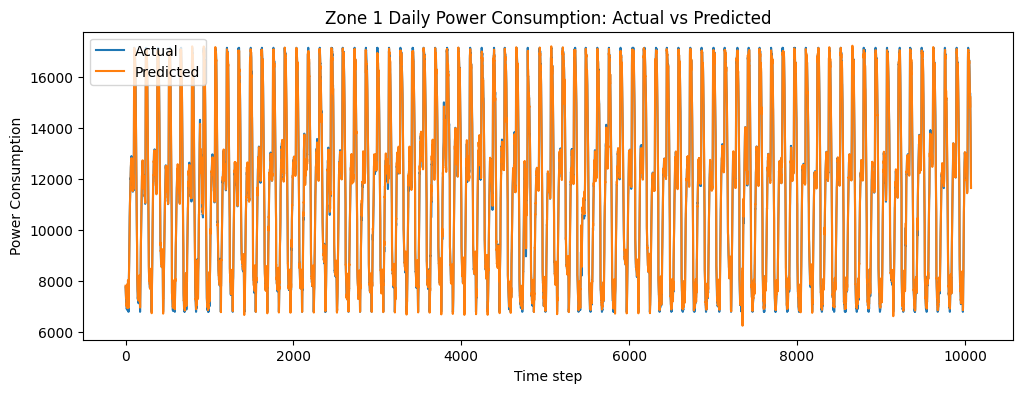


Zone 2 - TOTAL: RMSE: 0.02, MAE: 0.01, R²: 1.00


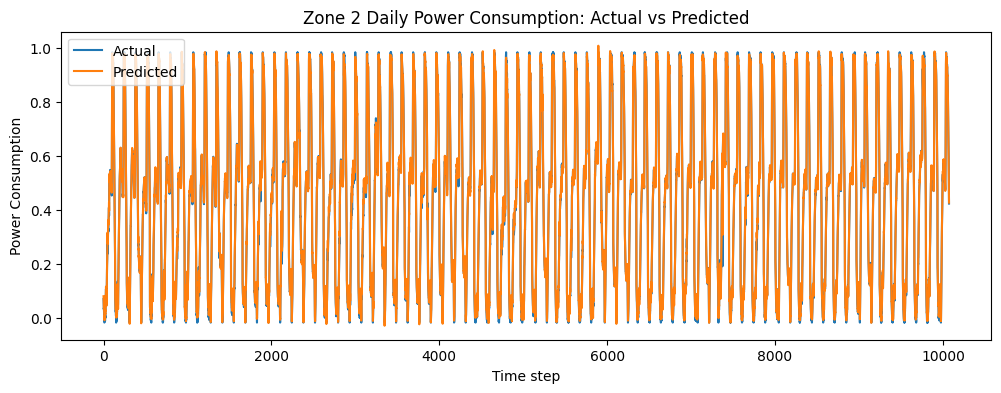


Zone 3 - TOTAL: RMSE: 0.02, MAE: 0.02, R²: 0.99


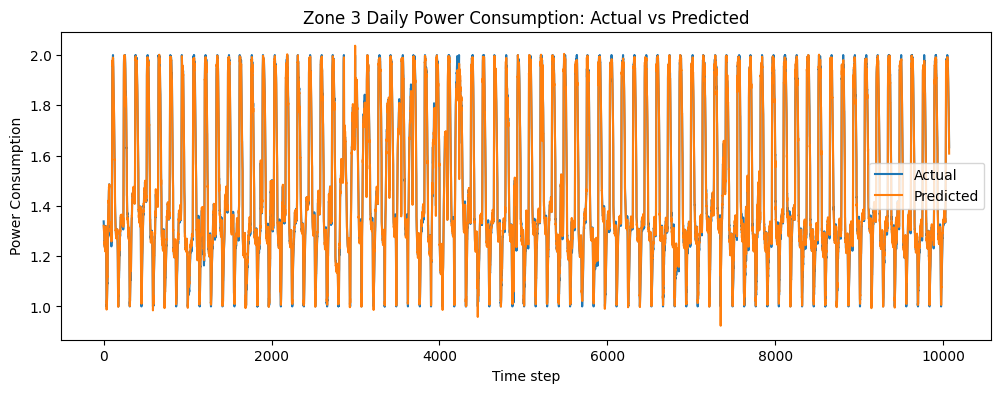

In [16]:
y_pred = best_model.predict(X_test)
# Inverse transform predictions. Pad zeros for the non-target features:
pad_cols = n_features - n_output_features
zeros_for_pred = np.zeros((y_pred.reshape(-1, n_output_features).shape[0], pad_cols))
pred_full  = np.concatenate([zeros_for_pred, y_pred.reshape(-1, n_output_features)], axis=1)
inv_pred = scaler_test.inverse_transform(pred_full)[:, -n_output_features:]
inv_pred = inv_pred.reshape(y_pred.shape)
zeros_for_true = np.zeros((y_test.reshape(-1, n_output_features).shape[0], pad_cols))
true_full = np.concatenate( [zeros_for_true, y_test.reshape(-1, n_output_features)], axis=1)
inv_true = scaler_test.inverse_transform(true_full)[:, -n_output_features:]
inv_true = inv_true.reshape(y_test.shape)


# Print Total and Daily Scores for Each Zone
best_loss = float('inf')


# Evaluate on the validation set
val_loss = history.history['val_loss'][-1]



zones = ['Zone 1', 'Zone 2', 'Zone 3']
timesteps_per_day = window_size

for i, zone in enumerate(zones):

    y_true = inv_true[:, 0, i]  
    y_pred = inv_pred[:, 0, i]  

    # Total metrics
    rmse_total = np.sqrt(mean_squared_error(y_true, y_pred))
    mae_total = mean_absolute_error(y_true, y_pred)
    r2_total = r2_score(y_true, y_pred)
    print(f'\n{zone} - TOTAL: RMSE: {rmse_total:.2f}, MAE: {mae_total:.2f}, R²: {r2_total:.2f}')

    # Daily metrics
    num_days = len(y_true) // timesteps_per_day

    #Mean of Daily Scores
    daily_rmse = []
    daily_mae = []
    daily_r2 = []
    for day in range(num_days):
        start = day * timesteps_per_day
        end = start + timesteps_per_day
        daily_rmse.append(np.sqrt(mean_squared_error(y_true[start:end], y_pred[start:end])))
        daily_mae.append(mean_absolute_error(y_true[start:end], y_pred[start:end]))
        daily_r2.append(r2_score(y_true[start:end], y_pred[start:end]))
    


    # Plot actual vs predicted
    plt.figure(figsize=(12, 4))
    plt.plot(y_true, label='Actual')
    plt.plot(y_pred, label='Predicted')
    plt.title(f'{zone} Daily Power Consumption: Actual vs Predicted')
    plt.xlabel('Time step')
    plt.ylabel('Power Consumption')
    plt.legend()
    plt.show()

In [20]:
# Evaluate prediction against the actual using RMSE or MAE or R2-Score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
def evaluate_model(model, X_test, y_test):

    # Predict
    y_pred = model.predict(X_test)
    # Inverse transform predictions (reshape as needed)
    y_pred_flat = y_pred.reshape(-1, 3)
    y_pred_inv = scaler_test.inverse_transform(np.concatenate([np.zeros((y_pred_flat.shape[0], X_test.shape[2]-3)), y_pred_flat], axis=1))[:, -3:]  # Only get the target columns


    mae = mean_absolute_error(y_test.flatten(), y_pred.flatten())
    rmse = np.sqrt(mean_squared_error(y_test.flatten(), y_pred.flatten()))
    r2 = r2_score(y_test.flatten(), y_pred.flatten())


    print(f'Mean Absolute Error: {mae}')
    print(f'Root Mean Squared Error: {rmse}')
    print(f'R² Score: {r2}')

    return y_pred, y_test


315/315 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
Mean Absolute Error: 0.012780723275042436
Root Mean Squared Error: 0.018873841790127854
R² Score: 0.996241897901265
Zone 1 - RMSE: 176.14, MAE: 124.71, R²: 1.00


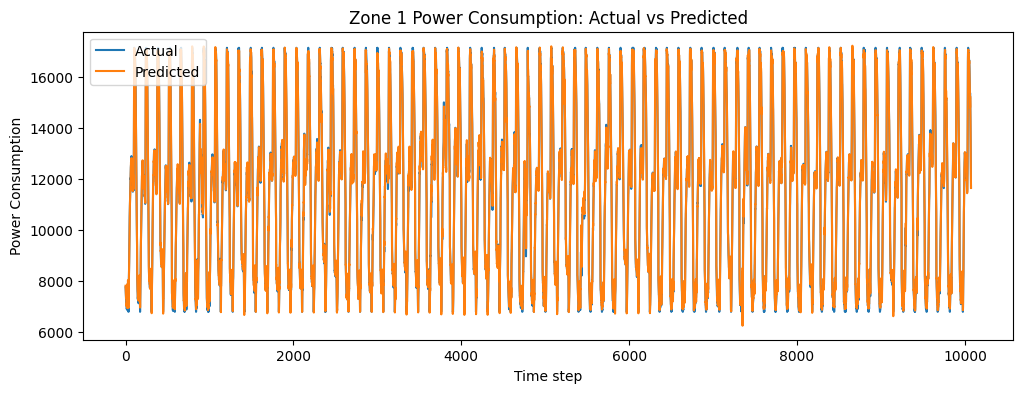

Zone 2 - RMSE: 0.02, MAE: 0.01, R²: 1.00


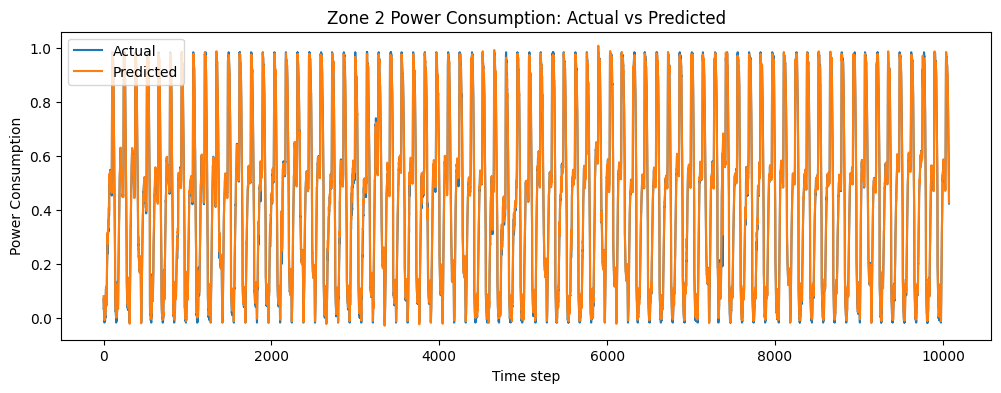

Zone 3 - RMSE: 0.02, MAE: 0.02, R²: 0.99


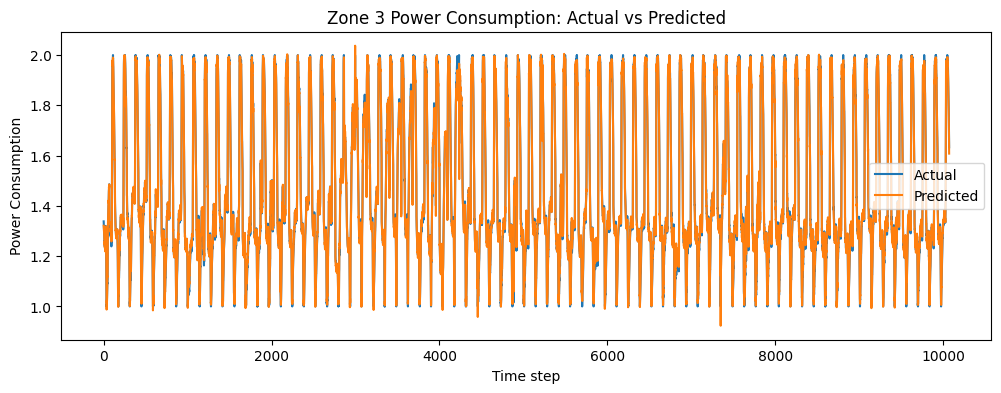

In [ ]:

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# Evaluate and plot predictions for all zones with correct shape handling
y_pred, y_test = evaluate_model(best_model, X_test, y_test)
n_features = X_test.shape[2]  
n_targets = 3  

# Flatten predictions and targets to 2D (samples*timesteps, n_targets)
y_pred_flat = y_pred.reshape(-1, n_targets)
y_test_flat = y_test.reshape(-1, n_targets)

# Pad with zeros for non-target columns to match scaler input shape
y_pred_padded = np.concatenate([np.zeros((y_pred_flat.shape[0], n_features - n_targets)), y_pred_flat], axis=1)
y_test_padded = np.concatenate([np.zeros((y_test_flat.shape[0], n_features - n_targets)), y_test_flat], axis=1)

# Inverse transform
try:
    y_pred_inv = scaler_test.inverse_transform(y_pred_padded)[:, -n_targets:]
    y_test_inv = scaler_test.inverse_transform(y_test_padded)[:, -n_targets:]  ##check
except Exception as e:
    print('Inverse transform error:', e)
    y_pred_inv = y_pred_flat
    y_test_inv = y_test_flat

# Calculate metrics for each target (zone)
for i, zone in enumerate(['Zone 1', 'Zone 2', 'Zone 3']):
    rmse = np.sqrt(mean_squared_error(y_test_inv[:, i], y_pred_inv[:, i]))
    mae = mean_absolute_error(y_test_inv[:, i], y_pred_inv[:, i])
    r2 = r2_score(y_test_inv[:, i], y_pred_inv[:, i])
    print(f'{zone} - RMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.2f}')
    
    # Plot actual vs predicted
    plt.figure(figsize=(12, 4))
    plt.plot(y_test_inv[:, i], label='Actual')
    plt.plot(y_pred_inv[:, i], label='Predicted')
    plt.title(f'{zone} Power Consumption: Actual vs Predicted')
    plt.xlabel('Time step')
    plt.ylabel('Power Consumption')
    plt.legend()
    plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

def walk_forward_forecast(model, test_groups_scaled, scaler, input_days=window_size, output_days=1, target_columns=['Zone 1 Power Consumption', 'Zone 2  Power Consumption','Zone 3  Power Consumption']):

    """
    Walk-forward validation: 
    """


    history = [group.copy() for group in test_groups_scaled[:2]]  # start with first 2 weeks
    predictions = []
    actuals = []
    n_features = history[0].shape[1]
    n_targets = len(target_columns)
    target_indices = [history[0].columns.get_loc(col) for col in target_columns]

    for i in range(2, len(test_groups_scaled)):
        # Prepare input from last two weeks
        input_data = pd.concat(history[-2:])
        X = []
        for j in range(len(input_data) - input_days + 1):
            X.append(input_data.iloc[j:j + input_days].values)
        X = np.array(X)
        if X.shape[0] == 0:
            continue
        # Predict next week
        y_pred = model.predict(X[-1:])  # use the last window
        # Inverse transform prediction
        y_pred_flat = y_pred.reshape(-1, n_targets)
        y_pred_padded = np.concatenate([np.zeros((y_pred_flat.shape[0], n_features - n_targets)), y_pred_flat], axis=1)
        y_pred_inv = scaler.inverse_transform(y_pred_padded)[:, -n_targets:]
        predictions.append(y_pred_inv)
        # Get actual next week
        actual_week = test_groups_scaled[i].iloc[:output_days, target_indices].values
        actual_padded = np.concatenate([np.zeros((actual_week.shape[0], n_features - n_targets)), actual_week], axis=1)
        actual_inv = scaler.inverse_transform(actual_padded)[:, -n_targets:]
        actuals.append(actual_inv)
        # Update history with actual week
        history.append(test_groups_scaled[i])
    # Stack predictions and actuals
    predictions = np.vstack(predictions)
    actuals = np.vstack(actuals)
    # Print total and daily scores for each zone
    for idx, zone in enumerate(['Zone 1', 'Zone 2', 'Zone 3']):
        rmse = np.sqrt(mean_squared_error(actuals[:, idx], predictions[:, idx]))
        mae = mean_absolute_error(actuals[:, idx], predictions[:, idx])
        r2 = r2_score(actuals[:, idx], predictions[:, idx])
        print(f'{zone} - Total RMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.2f}')
        # Daily scores
        print(f'{zone} - Daily scores:')

        for d in range(output_days):
            if d >= predictions.shape[0] // output_days:
                break
            day_pred = predictions[d::output_days, idx]
            day_actual = actuals[d::output_days, idx]
            day_rmse = np.sqrt(mean_squared_error(day_actual, day_pred))
            day_mae = mean_absolute_error(day_actual, day_pred)
            print(f'  Day {d+1}: RMSE={day_rmse:.2f}, MAE={day_mae:.2f}')
        # Plot
        plt.figure(figsize=(12, 4))
        plt.plot(actuals[:, idx], label='Actual')
        plt.plot(predictions[:, idx], label='Predicted')
        plt.title(f'{zone} Power Consumption: Actual vs Predicted (Walk-forward)')
        plt.xlabel('Time step')
        plt.ylabel('Power Consumption')
        plt.legend()
        plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━

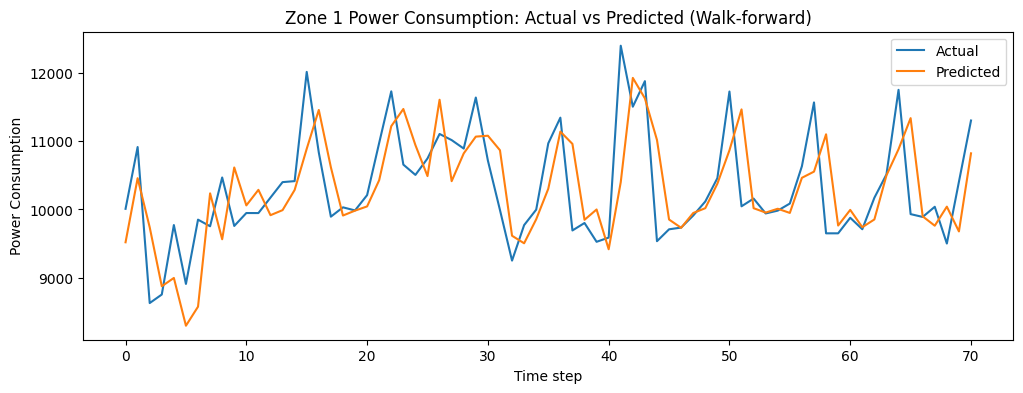

Zone 2 - Total RMSE: 0.10, MAE: 0.07, R²: -0.13
Zone 2 - Daily scores:
  Day 1: RMSE=0.10, MAE=0.07


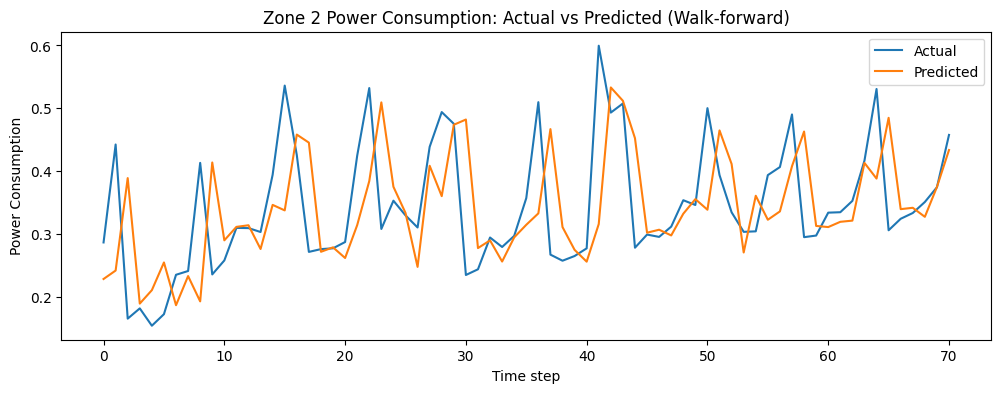

Zone 3 - Total RMSE: 0.06, MAE: 0.04, R²: 0.19
Zone 3 - Daily scores:
  Day 1: RMSE=0.06, MAE=0.04


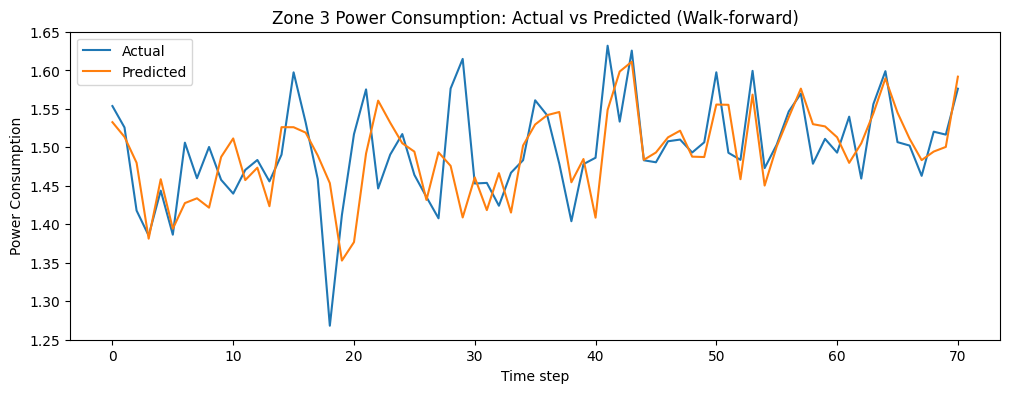

In [ ]:
walk_forward_forecast(best_model, test_groups_scaled, scaler_test, input_days=6, output_days=1, target_columns=['Zone 1 Power Consumption', 'Zone 2  Power Consumption','Zone 3  Power Consumption'])